# Constant-Coefficient Poisson Equation

We want to solve 

$$\phi_{xx} + \phi_{yy} = -2[(1-6x^2)y^2(1-y^2) + (1-6y^2)x^2(1-x^2)]$$

on 

$$[0,1]\times [0,1]$$ 

with homogeneous Dirichlet boundary conditions (this example comes from _A Multigrid Tutorial_).

This has the analytic solution
$$u(x,y) = (x^2 - x^4)(y^4 - y^2)$$

In [1]:
import numpy as np
import matplotlib.pyplot as plt

## Setting up the solver

We start by setting up a multigrid object&mdash;this needs to know the number of zones our problem is defined on

In [2]:
import pyro.multigrid.MG as MG

In [3]:
nx = ny = 256
mg = MG.CellCenterMG2d(nx, ny, 
                       xl_BC_type="dirichlet", xr_BC_type="dirichlet",
                       yl_BC_type="dirichlet", yr_BC_type="dirichlet", verbose=1)

cc data: nx = 2, ny = 2, ng = 1
         nvars = 3
         variables:
               v: min:    0.0000000000    max:    0.0000000000
                  BCs: -x: dirichlet    +x: dirichlet    -y: dirichlet    +y: dirichlet   
               f: min:    0.0000000000    max:    0.0000000000
                  BCs: -x: dirichlet    +x: dirichlet    -y: dirichlet    +y: dirichlet   
               r: min:    0.0000000000    max:    0.0000000000
                  BCs: -x: dirichlet    +x: dirichlet    -y: dirichlet    +y: dirichlet   

cc data: nx = 4, ny = 4, ng = 1
         nvars = 3
         variables:
               v: min:    0.0000000000    max:    0.0000000000
                  BCs: -x: dirichlet    +x: dirichlet    -y: dirichlet    +y: dirichlet   
               f: min:    0.0000000000    max:    0.0000000000
                  BCs: -x: dirichlet    +x: dirichlet    -y: dirichlet    +y: dirichlet   
               r: min:    0.0000000000    max:    0.0000000000
                  BCs: -

Next, we initialize the RHS.  To make life easier, the `CellCenterMG2d` object has the coordinates of the solution grid (including ghost cells) as `mg.x2d` and `mg.y2d` (these are two-dimensional arrays).

In [4]:
def rhs(x, y):
    return -2.0 * ((1.0 - 6.0 * x**2) * y**2 * (1.0 - y**2) +
                   (1.0 - 6.0 * y**2) * x**2 * (1.0 - x**2))

In [5]:
mg.init_RHS(rhs(mg.x2d, mg.y2d))

Source norm =  1.097515813669473


The last setup step is to initialize the solution--this is the starting point for the solve.  Usually we just want to start with all zeros, so we use the `init_zeros()` method

In [6]:
mg.init_zeros()

## Performing the solve

We can now solve&mdash;there are actually two different techniques we can do here.  We can just do pure smoothing on the solution grid using `mg.smooth(mg.nlevels-1, N)`, where `N` is the number of smoothing iterations.  To get the solution `N` will need to be large and this will take a long time.

Multigrid accelerates the smoothing.  We can do a V-cycle multigrid solution using `mg.solve()`

In [7]:
mg.solve()

source norm =  1.097515813669473
<<< beginning V-cycle (cycle 1) >>>

  level =  7, nx =  256, residual change:     1.09752 →     1.50231
  level =  6, nx =  128, residual change:     1.06162 →     1.43215
  level =  5, nx =   64, residual change:     1.01137 →     1.28187
  level =  4, nx =   32, residual change:    0.903531 →    0.960758
  level =  3, nx =   16, residual change:    0.673611 →    0.443977
  level =  2, nx =    8, residual change:    0.307211 →   0.0727216
  level =  1, nx =    4, residual change:   0.0484181 → 3.96107e-05
  bottom solve
  level =  1, nx =    4, residual change: 3.92501e-05 → 3.92501e-05
  level =  2, nx =    8, residual change:   0.0701013 →   0.0701013
  level =  3, nx =   16, residual change:    0.430738 →    0.430738
  level =  4, nx =   32, residual change:    0.911086 →    0.911086
  level =  5, nx =   64, residual change:     1.19454 →     1.19454
  level =  6, nx =  128, residual change:     1.31346 →     1.31346
  level =  7, nx =  256, residu

  level =  6, nx =  128, residual change: 1.58746e-07 → 1.88625e-07
  level =  5, nx =   64, residual change: 1.32945e-07 → 1.39771e-07
  level =  4, nx =   32, residual change: 9.83693e-08 → 8.26903e-08
  level =  3, nx =   16, residual change: 5.80625e-08 → 3.03473e-08
  level =  2, nx =    8, residual change: 2.11691e-08 → 5.46752e-09
  level =  1, nx =    4, residual change: 3.64181e-09 → 2.98263e-12
  bottom solve
  level =  1, nx =    4, residual change: 2.95548e-12 → 2.95548e-12


  level =  2, nx =    8, residual change: 5.27361e-09 → 5.27361e-09
  level =  3, nx =   16, residual change:  3.4147e-08 →  3.4147e-08
  level =  4, nx =   32, residual change: 1.03125e-07 → 1.03125e-07
  level =  5, nx =   64, residual change: 1.75853e-07 → 1.75853e-07


  level =  6, nx =  128, residual change: 2.33838e-07 → 2.33838e-07
  level =  7, nx =  256, residual change: 2.75928e-07 → 2.75928e-07
cycle 5: relative err = 0.005391244339065406, residual err = 4.933769007818501e-09

<<< beginning V-cycle (cycle 6) >>>

  level =  7, nx =  256, residual change: 5.41489e-09 → 4.94814e-09
  level =  6, nx =  128, residual change: 3.49296e-09 → 4.15445e-09
  level =  5, nx =   64, residual change: 2.92888e-09 → 3.07478e-09
  level =  4, nx =   32, residual change: 2.16499e-09 → 1.78803e-09
  level =  3, nx =   16, residual change: 1.25622e-09 → 6.02198e-10
  level =  2, nx =    8, residual change: 4.20281e-10 → 1.06557e-10
  level =  1, nx =    4, residual change: 7.09787e-11 → 5.81351e-14
  bottom solve
  level =  1, nx =    4, residual change: 5.76061e-14 → 5.76061e-14
  level =  2, nx =    8, residual change: 1.02789e-10 → 1.02789e-10
  level =  3, nx =   16, residual change: 6.91401e-10 → 6.91401e-10
  level =  4, nx =   32, residual change: 2.2570

## Plotting the solution

We can access the solution on the finest grid using `get_solution()`

In [8]:
phi = mg.get_solution()

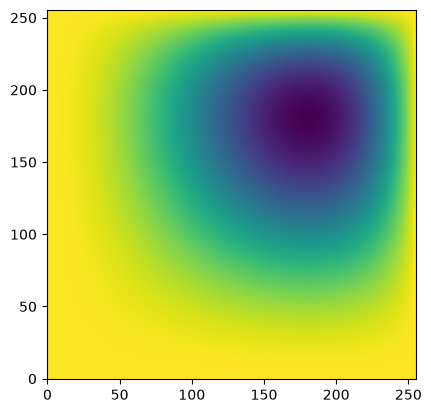

In [9]:
fig, ax = plt.subplots()
ax.imshow(np.transpose(phi.v()), origin="lower")

We can also get the gradient of the solution

In [10]:
gx, gy = mg.get_solution_gradient()

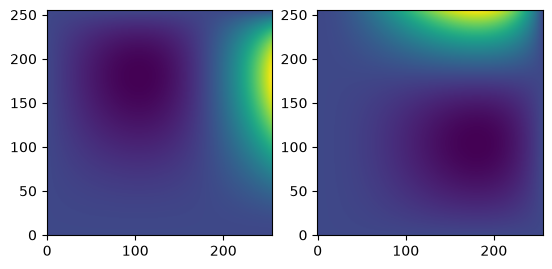

In [11]:
fig = plt.figure()

ax = fig.add_subplot(121)
ax.imshow(np.transpose(gx.v()), origin="lower")

ax = fig.add_subplot(122)
ax.imshow(np.transpose(gy.v()), origin="lower")